# GSS cash-bond butterfly — UST

A port of the GSS curve-fitting RV process onto US Treasuries, running on ARBS's
`QueryDrivenBacktest`.

**What the strategy is.** Fit a curve across the coupon complex; a bond's *yield error* against
that curve is its richness. Blend a time-series score (rich versus its own history) with a
cross-sectional score (rich versus its peers today). Rank every eligible bond by |richness|, and
for each one as a **belly**, pick the wings inside a maturity window that maximise the richness
gap. Weight by maturity — belly `+1`, wings summing to `-1`, so the fly is maturity-neutral and
explicitly *not* DV01-neutral. Sign the whole thing by the fly's own z so the position always
faces mean reversion. Enter when the vol-scaled signal `ZSig = |z|·σ_fly` exceeds a basis-point
threshold **and** |z| has already begun to shrink; exit when `ZSig` decays below the repo hurdle.

**Why UST and not EGB.** The original ran on eleven European sovereign curves. ARBS has no non-US
bond reference data and no validated Citi tags for non-US ISINs, so the universe is re-targeted.
Everything else is the original's.

**Three deliberate deviations from the source**, each a config knob, each visible below:

1. `wing_selection` in the original maximises `|Signal_wing − belly.TimeToMaturity|` — it subtracts
   a maturity *in years* from a *z-score*. Almost certainly a typo for `Signal_belly`. The default
   here is the corrected objective; `legacy_ttm_bug` reproduces the original.
2. The original charges its bid/offer on **the belly only** and says so. That flatters a
   three-legged trade, so the default charges all three legs weighted by |w|.
3. Repo is not the original's flat `-(r/360)·days`. ARBS's `FinancedFixedRateBondHandler` already
   prices financing per leg from a GC curve plus per-leg specialness on ACT/360, so the book hands
   it the curve and lets the engine do it.

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ.setdefault("ARBS_SUPABASE_ENABLED", "0")

import sys, datetime, logging
sys.path.append("../../")

import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
plt.style.use("seaborn-v0_8-dark")
pylab.rcParams.update({"figure.figsize": (20, 8), "axes.titlesize": "x-large", "axes.labelsize": "large"})

import warnings
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.ERROR)

# Required, not decorative. `FixedRateBondsMDP._get_multi_pricers` falls back to
# `WSJFetcher.ust_intraday_timeseries` for any CUSIP FedInvest has not published, and that fetcher
# calls `asyncio.run()` — which raises "cannot be called from a running event loop" inside a Jupyter
# kernel. The fallback is reachable on ANY date (coverage is per-CUSIP, not per-day), so pinning
# `as_of` to an older date does not avoid it.
import nest_asyncio
nest_asyncio.apply()

from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue
from TB.FixedRateBondsTB import FixedRateBondsTB
from TB.TimeseriesBuilder import TimeseriesBuilder

from RVUtils.Interpolation.GeneralCurveInterpolator import GeneralCurveInterpolator
from RVUtils.ust_viz import plot_usts, plot_usts_comparison
from RVUtils.plt_timeseries import make_secondary_axis_plot

from BT.gss_fly import (
    GSSConfig, FlyConfig, CostConfig, BacktestConfig,
    build_curve_panel, build_bond_signals, apply_universe_filter,
    scan_flies, select_wings, build_weights, fly_tcost_bp,
    load_repo_from_workbook, resolve_repo_curve, repo_tag_grid,
)
from BT.gss_fly.backtest import run_gss_backtest
from BT.gss_fly.data import ust_business_days

usts_mdp = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-QL")
tb = TimeseriesBuilder(fixedratebonds_tb=FixedRateBondsTB(usts_mdp))

cfg = GSSConfig()
print(cfg.describe())

gss_fly: signal 0.75·TS + 0.25·XS (smooth hl=3, score com=20) | universe cpn<7 ttm>=3 season>=50d | wings signal_gap ±2/5y | entry ZSig>3bp exit<=2.5bp | costs all


## 1. The curve, and the spline the richness is measured against

In [2]:
as_of = datetime.date(2026, 8, 11)

ref_df = (
    usts_mdp.get_bond_reference_data(as_of_date=as_of)
    .drop(columns=["record_date"])
    .rename(columns={"label": "ust_label"})
)
ref_df = ref_df[ref_df["ttm"] >= 1]

pricers = usts_mdp.get_pricer(
    request=dict(cusips=ref_df["cusip"].to_list(),
                 timestamp="live" if as_of == datetime.date.today() else as_of,
                 show_tqdm=True)
)
ref_df["mdur"] = ref_df["cusip"].apply(lambda c: pricers[c].mod_duration() if c in pricers else np.nan)
market_df = pd.DataFrame([{"cusip": c, "ytm": p.ytm()} for c, p in pricers.items()]).merge(ref_df, on="cusip")

# The GSS universe excludes the on-the-runs: their specialness in repo is not priced by a GC
# hurdle, so a rich OTR is not a tradeable richness.
cusips_to_fit = ref_df[~ref_df["rank"].isin([0, 1, 2])]["cusip"].to_list()
ttm = [pricers[c].time_to_maturity() for c in cusips_to_fit if c in pricers]
ytm = [pricers[c].ytm() for c in cusips_to_fit if c in pricers]

# The spline build from usts_rv.ipynb, unchanged.
ytm_bspline = GeneralCurveInterpolator(x=ttm, y=ytm).b_spline_with_knots_interpolation(
    knots=[2, 3, 5, 7, 10, 20, 25], k=3, return_func=True
)
ytm_loess = GeneralCurveInterpolator(x=ttm, y=ytm).loess_interpolation(frac=0.15, it=50, delta=0, return_func=True)

plot_usts(
    curve_set_df=market_df,
    ttm_col="ttm",
    ytm_col="ytm",
    label_col="oi",
    cusip_col="cusip",
    hover_data=ref_df.columns.to_list(),
    splines=[(ytm_bspline, "BSpline", "red"), (ytm_loess, "LOESS", "orange")],
    title=f"UST complex and the fitted curve — {as_of}",
)

FETCHING DATA FROM WSJ...:   0%|          | 0/3 [00:00<?, ?it/s]

FETCHING DATA FROM WSJ...:  33%|███▎      | 1/3 [00:00<00:00,  3.14it/s]

FETCHING DATA FROM WSJ...: 100%|██████████| 3/3 [00:00<00:00,  8.81it/s]

### 1.1 The same curve a month earlier

`plot_usts_comparison` overlays two dates on one colour map, which is how a dislocation that has
*persisted* is told from one that has just appeared — the entry gate cares about the difference.

In [3]:
# NOT `as_of - timedelta(days=30)` on its own: that landed on Sunday 2026-07-12, FedInvest has no
# snapshot for it, every one of the 295 pricers failed, and the empty frame then died in the merge
# with `KeyError: 'cusip'` — a calendar bug wearing a pandas error. Snap back to the last UST
# trading day on or before the target. Same landmine as `pd.bdate_range` vs `ust_business_days`.
_target = as_of - datetime.timedelta(days=30)
compare = ust_business_days(_target - datetime.timedelta(days=10), _target)[-1]

old_ref = (
    usts_mdp.get_bond_reference_data(as_of_date=compare)
    .drop(columns=["record_date"]).rename(columns={"label": "ust_label"})
)
old_ref = old_ref[old_ref["ttm"] >= 1]
old_pricers = usts_mdp.get_pricer(request=dict(cusips=old_ref["cusip"].to_list(), timestamp=compare, show_tqdm=True))
# Say what actually went wrong. An empty fetch produces a frame with no columns, and the merge below
# then raises `KeyError: 'cusip'` — which reads as a schema bug and is really "the source served
# nothing for this date". The MDP logs each failure at WARNING and returns normally, so without this
# the only signal is 295 warnings scrolling past followed by an unrelated-looking exception.
if not old_pricers:
    raise RuntimeError(f"no pricers for {compare} — FedInvest served nothing for that date")
old_market = pd.DataFrame([{"cusip": c, "ytm": p.ytm()} for c, p in old_pricers.items()]).merge(old_ref, on="cusip")

old_fit = old_ref[~old_ref["rank"].isin([0, 1, 2])]["cusip"].to_list()
old_bspline = GeneralCurveInterpolator(
    x=[old_pricers[c].time_to_maturity() for c in old_fit if c in old_pricers],
    y=[old_pricers[c].ytm() for c in old_fit if c in old_pricers],
).b_spline_with_knots_interpolation(knots=[2, 3, 5, 7, 10, 20, 25], k=3, return_func=True)

fig, cmap = plot_usts_comparison(
    curve_set_df=old_market, ttm_col="ttm", ytm_col="ytm", label_col="oi", cusip_col="cusip",
    hover_data=old_ref.columns.to_list(), splines=[(old_bspline, "BSpline", "lightcoral")],
    opacity=0.45, name_suffix=str(compare), show=False, return_color_map=True,
)
plot_usts_comparison(
    curve_set_df=market_df, ttm_col="ttm", ytm_col="ytm", label_col="oi", cusip_col="cusip",
    hover_data=ref_df.columns.to_list(), splines=[(ytm_bspline, "BSpline", "red")],
    title=f"UST complex: {compare} vs {as_of}",
    fig=fig, opacity=1.0, name_suffix=str(as_of), color_discrete_map=cmap, show=True,
)

FETCHING CUSIPS...:   0%|          | 0/295 [00:00<?, ?it/s]

FETCHING CUSIPS...:   5%|▍         | 14/295 [00:00<00:02, 135.70it/s]

FETCHING CUSIPS...:   9%|▉         | 28/295 [00:00<00:01, 133.64it/s]

FETCHING CUSIPS...:  14%|█▍        | 42/295 [00:00<00:01, 135.02it/s]

FETCHING CUSIPS...:  19%|█▉        | 57/295 [00:00<00:01, 137.46it/s]

...

FETCHING CUSIPS...:  86%|████████▋ | 255/295 [00:02<00:00, 118.41it/s]

FETCHING CUSIPS...:  91%|█████████ | 268/295 [00:02<00:00, 119.63it/s]

FETCHING CUSIPS...:  95%|█████████▍| 280/295 [00:02<00:00, 118.18it/s]

FETCHING CUSIPS...:  99%|█████████▉| 292/295 [00:02<00:00, 115.42it/s]

FETCHING CUSIPS...: 100%|██████████| 295/295 [00:02<00:00, 119.91it/s]

## 2. The curveset at an instant — CVSNAP

`build_curve_panel` marks on the FedInvest/WSJ close, which is what the backtest wants. When the
question is instead *what did the whole complex look like at 10:35 on the day of the auction*,
that is a snapshot, and it comes from Citi Velocity's `CVSNAP`.

The guard matters more than the call. Citi resolves **as-of**, so a request for an instant the
wire never published silently returns an earlier one. `fetch_curveset_snapshot` attaches the stamp
it actually resolved to and refuses a resolution staler than the tolerance.

This needs a signed-in Excel with the Velocity add-in; the cell reports and moves on if not.

In [4]:
from BT.gss_fly import fetch_curveset_snapshot, warm_bond_snapshots, BOND_SNAPSHOT_VALUES

snap_when = pd.Timestamp(f"{as_of} 15:00:00")
try:
    snap = fetch_curveset_snapshot(
        snap_when,
        reference=ref_df.head(60),          # widen once the warm below has been run
        values=BOND_SNAPSHOT_VALUES,
        max_staleness=datetime.timedelta(days=1),
        strict=True,
    )
    print(f"resolved {len(snap)} bonds at {snap['snap_stamp'].iloc[0]} (requested {snap_when})")
    display(snap[["isin", "yield", "price", "duration", "ttm", "oi"]].head(12))
except Exception as exc:
    print(f"CVSNAP unavailable: {type(exc).__name__}: {exc}")
    print("Run scripts/warm_citivelo_xccy_repo.py with Excel signed in, then retry.")

# Cache warm — pull the history once so later snapshots resolve from disk rather than the wire.
# warm_bond_snapshots(ref_df["cusip"].tolist(), start="2024-01-01", end=str(as_of))

CVSNAP unavailable: RuntimeError: Citi Velocity snapshot unavailable (ExcelNotRunningError: No running Excel with the Citi Velocity add-in. Open Excel and sign in to Velocity, then retry. (The bridge attaches to a human-authenticated Excel; it never spawns one, because spawned instances never register the CV* UDFs.)). The bridge attaches to a human-authenticated Excel with the Velocity add-in signed in; it cannot spawn one.
Run scripts/warm_citivelo_xccy_repo.py with Excel signed in, then retry.


## 3. The panel, the signal, and the flies

In [5]:
from pathlib import Path

# The SAME window and the SAME cache the sweep, the cost table and the configurable-backtest
# notebook use, so the numbers below corroborate those rather than introducing a third set a reader
# has to reconcile. It also ends where the data is known good.
#
# It used to run to `as_of`, and that is how the zero-price days were found: FedInvest published
# `eod_price = 0.0` for all 463 bonds on nine days in 2026-07/08 while bid/offer stayed sane, the
# spline fitted a curve through 605%-5,408% yields, and this book's equity reached $178 trillion.
# `BT/gss_fly/data.py::_day_is_usable` now refuses such a day on both fetch and cache read, so the
# extended range is safe to run again — it is pinned here for comparability, not for safety.
PANEL_CACHE = Path("../data/gss_fly/panel_cached")
start, end = datetime.date(2024, 9, 2), datetime.date(2026, 1, 2)

# NOT pd.bdate_range: it includes market holidays, which the source never serves and whose fetcher
# HANGS rather than refusing. One Labor Day stalled two separate panel builds.
days = ust_business_days(start, end)

panel = build_curve_panel(days, usts_mdp, cache_path=PANEL_CACHE)
print(panel.summary())

sig = build_bond_signals(panel.s2c, cfg.signal)
print(f"signal: {sig['signal'].shape[1]} bonds x {sig['signal'].shape[0]} dates, "
      f"{int(sig['signal'].notna().sum().sum()):,} observations")

CurvePanel 332 dates 2024-09-03..2026-01-02, 343 bonds, median RMSE 1.94bp


signal: 343 bonds x 332 dates, 100,330 observations


In [6]:
asof = panel.dates[-1]
curve = panel.curve_on(asof)
curve["signal"] = sig["signal"].loc[asof].reindex(curve.index)
elig = apply_universe_filter(curve, cfg.universe)
print(f"{len(curve)} bonds -> {len(elig)} eligible "
      f"(coupon<{cfg.universe.max_coupon:g}, ttm>={cfg.universe.min_ttm:g}, "
      f"seasoning>={cfg.universe.min_seasoning_days:g}d, ex-OTR)")

flies = scan_flies(elig, s2c_panel=panel.s2c, yield_panel=panel.ytm, asof=asof, cfg=cfg.fly)
top = sorted(flies, key=lambda f: -f.zsig_bp)[:15]
display(pd.DataFrame([{
    "fly": f.fly_id, "z": round(f.z, 2), "sigma_bp": round(f.std_bp, 2),
    "ZSig_bp": round(f.zsig_bp, 2), "d|z|": round(f.d_abs_z, 3),
    "weights": [round(w, 3) for w in f.weights], "ttms": [round(t, 1) for t in f.ttms],
    "rt_cost_bp": round(2 * fly_tcost_bp(f.ttms, f.weights, cfg.costs), 3),
} for f in top]))
print(f"\nentry gate: ZSig > {cfg.backtest.entry_zsig_bp:g}bp AND d|z| < 0  "
      f"-> {sum(1 for f in flies if f.zsig_bp > cfg.backtest.entry_zsig_bp and f.d_abs_z < 0)} of {len(flies)} qualify")

347 bonds -> 189 eligible (coupon<7, ttm>=3, seasoning>=50d, ex-OTR)


,fly,z,sigma_bp,ZSig_bp,d|z|,weights,ttms,rt_cost_bp
0,912810SH2-912810SN9-912810TG3,2.62,1.17,3.06,0.006,"[-0.667, 1.0, -0.333]","[23.4, 24.4, 26.4]",3.200
1,91282CCB5-912810FT0-912810SQ2,1.77,1.67,2.95,-0.159,"[0.486, -1.0, 0.514]","[5.4, 10.1, 14.6]",1.806
2,91282CKD2-912828YB0-91282CHR5,1.96,1.42,2.77,-0.193,"[-0.676, 1.0, -0.324]","[3.2, 3.6, 4.6]",1.000
3,91282CHT1-912810PW2-912810SQ2,1.21,2.20,2.66,-0.002,"[0.357, -1.0, 0.643]","[7.6, 12.1, 14.6]",1.929
4,912810FJ2-91282CFT3-91282CCB5,2.12,1.15,2.45,-0.654,"[0.879, -1.0, 0.121]","[3.6, 3.8, 5.4]",1.012
5,91282CKD2-912810FJ2-91282CHR5,1.87,1.27,2.36,-0.687,"[-0.676, 1.0, -0.324]","[3.2, 3.6, 4.6]",1.000
6,91282CJW2-912810FG8-91282CHR5,1.74,1.29,2.24,-0.146,"[-0.973, 1.0, -0.027]","[3.1, 3.1, 4.6]",1.000
7,912810RY6-912810SH2-912810SN9,2.63,0.82,2.15,-0.002,"[0.364, -1.0, 0.636]","[21.6, 23.4, 24.4]",3.200
8,912810RY6-912810SJ8-912810SN9,2.83,0.75,2.13,-0.148,"[0.272, -1.0, 0.728]","[21.6, 23.6, 24.4]",3.200
9,912810FJ2-91282CGJ4-91282CCB5,1.97,0.95,1.87,-0.391,"[0.735, -1.0, 0.265]","[3.6, 4.1, 5.4]",1.026



entry gate: ZSig > 3bp AND d|z| < 0  -> 0 of 175 qualify


### 3.1 The wing-selection deviation, side by side

The corrected objective and the original's are run on the same curve. Where they disagree, the
original is picking the wing whose *signal* is furthest from the belly's *time to maturity* — a
comparison between two different quantities.

In [7]:
rows = []
for belly in elig.dropna(subset=["signal"]).reindex(
        elig["signal"].abs().sort_values(ascending=False).index).dropna(subset=["signal"]).index[:12]:
    fixed = select_wings(elig, belly, FlyConfig(wing_objective="signal_gap"))
    legacy = select_wings(elig, belly, FlyConfig(wing_objective="legacy_ttm_bug"))
    if len(fixed) == 3 and len(legacy) == 3:
        rows.append({"belly": belly, "belly_ttm": round(elig.loc[belly, "ttm"], 1),
                     "signal_gap": "-".join(fixed), "legacy": "-".join(legacy),
                     "same": fixed == legacy})
cmp_df = pd.DataFrame(rows)
display(cmp_df)
print(f"the two objectives disagree on {int((~cmp_df['same']).sum())} of {len(cmp_df)} bellies")

,belly,belly_ttm,signal_gap,legacy,same
0,91282CHR5,4.6,912810FJ2-91282CHR5-91282CCB5,91282CFT3-91282CHR5-91282CMC2,False
1,912810SQ2,14.6,912810QH4-912810SQ2-912810UJ5,912810QH4-912810SQ2-912810UJ5,True
2,912810UJ5,19.1,912810SQ2-912810UJ5-912810RY6,912810QN1-912810UJ5-912810SH2,False
3,91282CCB5,5.4,91282CHR5-91282CCB5-91282CMC2,91282CHR5-91282CCB5-91282CMC2,True
4,912810SR0,14.4,912810FT0-912810SR0-912810UJ5,912810FT0-912810SR0-912810UJ5,True
5,912810QN1,15.1,912810SQ2-912810QN1-912810TS7,912810QL5-912810QN1-912810UJ5,False
6,912810SH2,23.4,912810RY6-912810SH2-912810SN9,912810SE9-912810SH2-912810SJ8,False
7,912810RY6,21.6,912810RX8-912810RY6-912810SH2,912810RX8-912810RY6-912810SH2,True
8,912810SJ8,23.6,912810RY6-912810SJ8-912810SN9,912810SH2-912810SJ8-912810SK5,False
9,912810QL5,14.9,912810SQ2-912810QL5-912810TS7,912810QH4-912810QL5-912810UJ5,False


the two objectives disagree on 6 of 12 bellies


## 4. Repo — the hurdle the exit is measured against

In [8]:
from pathlib import Path
REPO_XLSX = Path(r"C:/Users/chris/Downloads/gc_repo_hist_example.xlsx")

# `resolve_repo_curve` returns the basis as well as the curve, and prints it either way. There is
# NO flat-rate fallback: `CostConfig.fallback_repo_pct` is declared and read by nothing (it is one
# of the harness's planted nulls, pinned dead in tests/gss_fly/test_conditioning.py). Without a
# workbook the run is simply UNFINANCED — carry is not charged at all — so `basis` has to be
# carried into every number below rather than assumed.
repo, basis = resolve_repo_curve(REPO_XLSX, collateral="USTREASGC")
if repo is not None:
    display(repo.frame.tail(5)[["ON", "1W", "1M", "3M", "1Y"]])
    # The OTR specials are why the universe drops rank 0: a 10y OTR finances well below GC.
    otr = load_repo_from_workbook(REPO_XLSX, collateral="USD10YOTR")
    spread = (repo.frame["ON"] - otr.frame["ON"]).dropna()
    print(f"\n10y OTR special vs GC, overnight: median {spread.median()*100:.1f}bp, "
          f"max {spread.max()*100:.1f}bp over {len(spread)} days")
else:
    print("Online path: scripts/warm_citivelo_xccy_repo.py --what repo")
print("\nrepo tag grid:", repo_tag_grid()[:4], "...", len(repo_tag_grid()), "tags")

REPO: C:\Users\chris\Downloads\gc_repo_hist_example.xlsx does not exist
      UNFINANCED — no repo curve; carry is NOT charged and every P&L below is gross of funding
Online path: scripts/warm_citivelo_xccy_repo.py --what repo

repo tag grid: ['RATES.REPO.USD.USTREASGC.SPOT.ON', 'RATES.REPO.USD.USTREASGC.SPOT.TN', 'RATES.REPO.USD.USTREASGC.SPOT.1W', 'RATES.REPO.USD.USTREASGC.SPOT.1M'] ... 56 tags


## 5. The backtest — QueryDrivenBacktest

In [9]:
res = run_gss_backtest(
    panel, usts_mdp,
    cfg=cfg,
    repo_curve=repo,
    repo_tenor="ON",
    leg_specialness_bps={"belly": 0.0, "front": 0.0, "back": 0.0},
    show_progress=True,
)
print("diagnostics:", res.diagnostics)
print()
for k, v in res.summary().items():
    print(f"  {k:22s} {v}")

GSS FLY BACKTEST:   0%|          | 0/332 [00:00<?, ?step/s]

GSS FLY BACKTEST:   0%|          | 1/332 [00:00<01:48,  3.06step/s]

GSS FLY BACKTEST:   1%|          | 2/332 [00:00<01:52,  2.93step/s]

GSS FLY BACKTEST:   1%|          | 3/332 [00:01<01:54,  2.88step/s]

GSS FLY BACKTEST:   1%|          | 4/332 [00:01<01:57,  2.79step/s]

...

GSS FLY BACKTEST:  99%|█████████▉| 330/332 [05:26<00:02,  1.03s/step]

GSS FLY BACKTEST: 100%|█████████▉| 331/332 [05:27<00:01,  1.01s/step]

GSS FLY BACKTEST: 100%|██████████| 332/332 [05:28<00:00,  1.02s/step]

GSS FLY BACKTEST: 100%|██████████| 332/332 [05:28<00:00,  1.01step/s]

diagnostics: {'elapsed_s': 328.2, 'grid_days': 332, 'marked_days': 332, 'equity_holes': 0, 'first_holes': [], 'nonzero_marks': 303, 'signal_entries': 35, 'signal_exits': 34, 'closed_positions': 34, 'still_open': 1, 'median_rmse_bp': 1.9387173506076327}

  marked_days            332
  end_equity_usd         -4254352.40234792
  closed_trades          34
  daily_sharpe_ann       -1.9002705589285023
  max_dd_usd             -4812053.339155429
  carry_during_hold_usd  -7278912.578289493
  unwind_proceeds_usd    8217382.483658384
  fees_usd               -5637475.123364326
  open_mtm_usd           444652.8156475127
  bond_ledger_usd        938469.9053688908
  financing_ledger_usd   0.0
  gross_before_fees_usd  1383122.7210164052
  cost_share_of_gross    4.075903777519869
  breakeven_cost_multiplier 0.24534435908800725
  reconciliation_gap_usd 1.862645149230957e-09
  per_trade_pnl_usd      2579907.3602940585
  avg_per_trade_usd      75879.62824394289
  hit_rate_per_trade     0.294117647058823

In [10]:
eq = res.equity
fig = go.Figure()
fig.add_trace(go.Scatter(x=eq.index, y=eq.values, mode="lines", name="account value",
                         line=dict(color="#2F4B7C", width=2)))
fig.add_hline(y=0, line_dash="dash", line_color="grey")
fig.update_layout(template="plotly_dark", height=520,
                  title=f"GSS UST butterfly book — {len(eq)} marked days [{basis}]",
                  xaxis_title="", yaxis_title="USD")
fig.show()

if not res.closed.empty:
    c = res.closed.copy()
    p = c["realized_pnl"].astype(float)
    fig2 = go.Figure(go.Bar(x=pd.to_datetime(c["closed_at"]), y=p,
                            marker_color=["#2ca02c" if v > 0 else "#d62728" for v in p]))
    fig2.add_hline(y=0, line_color="white", line_dash="dash", opacity=0.5)
    fig2.update_layout(template="plotly_dark", height=380, title="Realised P&L per closed fly",
                       yaxis_title="USD")
    fig2.show()
    display(c[["opened_at", "closed_at", "holding_period_days", "realized_pnl",
               "gross_realized_pnl", "fee_allocated"]].head(15))

,opened_at,closed_at,holding_period_days,realized_pnl,gross_realized_pnl,fee_allocated
0,2024-10-11,2024-10-15,4.0,1.780762e+05,2.782543e+05,100178.082192
1,2024-10-11,2024-11-18,38.0,4.379469e+05,6.521953e+05,214248.434238
2,2024-10-31,2024-11-20,20.0,-1.608243e+06,-1.388264e+06,219979.155810
3,2024-11-20,2024-11-26,6.0,-2.304771e+05,-3.047712e+04,200000.000000
4,2024-11-21,2024-11-29,8.0,-1.884306e+05,3.823810e+04,226668.694859
5,2024-12-02,2024-12-05,3.0,-8.918337e+04,1.081663e+04,100000.000000
6,2024-12-03,2024-12-09,6.0,-1.952906e+05,4.709359e+03,200000.000000
7,2024-11-18,2024-12-16,28.0,-4.203634e+05,-1.978583e+05,222505.133470
8,2024-12-18,2024-12-24,6.0,-1.145063e+04,9.325297e+04,104703.608247
9,2024-12-26,2025-01-06,11.0,8.342180e+04,2.000702e+05,116648.451730


### 5.1 The trade log, and what the gates actually did

Every entry and exit the signal engine emitted, with the state that triggered it. The exit reason
is the interesting column: `zsig_below_repo` is the position decaying into the financing hurdle,
`z_rollover` is it turning back through the band.

In [11]:
log = res.trade_log
if not log.empty:
    display(log.tail(20))
    print("\nby event:"); display(log.groupby("event").size().to_frame("n"))
    ex = log[log["event"] == "EXIT"]
    if not ex.empty:
        print("by exit reason:")
        display(ex.groupby("reason").agg(n=("reason", "size"), median_held=("held_days", "median")))
    en = log[log["event"] == "ENTER"]
    if not en.empty:
        print(f"entry ZSig: median {en['zsig_bp'].median():.2f}bp, max {en['zsig_bp'].max():.2f}bp")

,date,event,tag,fly_id,z,zsig_bp,std_bp,d_abs_z,rt_cost_bp,weights,ttms,reason,held_days
49,2025-04-15,EXIT,gss00024,912810QE1-912810RH3-912810SA7,2.037801,2.325979,NaN,NaN,NaN,NaN,NaN,zsig_below_repo,6.0
50,2025-04-15,ENTER,gss00026,912810QE1-912810SR0-912810TW8,1.822386,3.652238,2.004097,-0.144408,2.000000,"[-0.9342585829072318, 1.0, -0.06574141709276812]","[14.838019312822816, 15.083920952167079, 18.58...",NaN,NaN
51,2025-04-28,EXIT,gss00026,912810QE1-912810SR0-912810TW8,1.063482,2.389044,NaN,NaN,NaN,NaN,NaN,zsig_below_repo,13.0
52,2025-05-07,ENTER,gss00027,91282CKC4-912810FT0-912810QH4,1.743866,3.175818,1.821136,-0.016039,1.815577,"[-0.46105826397146255, 1.0, -0.5389417360285373]","[5.813698630136987, 10.777745340220076, 15.023...",NaN,NaN
53,2025-05-15,EXIT,gss00027,91282CKC4-912810FT0-912810QH4,1.228875,2.148982,NaN,NaN,NaN,NaN,NaN,zsig_below_repo,8.0
54,2025-06-09,ENTER,gss00028,912810FF0-91282CHW4-91282CDY4,1.976487,3.205637,1.621887,-0.040307,1.155097,"[0.4490311710193765, -1.0, 0.5509688289806235]","[3.4359682610973876, 5.227397260273973, 6.6873...",NaN,NaN
55,2025-06-16,EXIT,gss00028,912810FF0-91282CHW4-91282CDY4,1.344576,2.288806,NaN,NaN,NaN,NaN,NaN,zsig_below_repo,7.0
56,2025-07-02,ENTER,gss00029,91282CKU4-912810FT0-912810QK7,1.768087,3.054623,1.727643,-0.025575,1.804637,"[-0.48840665873959566, 1.0, -0.5115933412604043]","[5.912328767123287, 10.624320682685829, 15.121...",NaN,NaN
57,2025-07-10,EXIT,gss00029,91282CKU4-912810FT0-912810QK7,1.367789,2.443360,NaN,NaN,NaN,NaN,NaN,zsig_below_repo,8.0
58,2025-07-21,ENTER,gss00030,912810QA9-912810QT8-912810RP5,2.183275,3.344083,1.531682,-0.080410,2.244381,"[-0.5926977687626777, 1.0, -0.4073022312373224]","[13.572602739726028, 16.32054794520548, 20.320...",NaN,NaN



by event:


,n
event,
ENTER,35
EXIT,34


by exit reason:


,n,median_held
reason,,
zsig_below_repo,34,7.5


entry ZSig: median 3.26bp, max 4.42bp


## 6. Timeseries — the fly, and the spline behind it

`FixedRateBondQuery` takes a slash-joined package, so a butterfly is a first-class timeseries
object. `SPLINE_SPREAD` is the same per-bond yield error the signal is built on, which means the
signal can be read straight off the same machinery that trades it.

FETCHING PRICERS:   0%|          | 0/332 [00:00<?, ?it/s]

FETCHING PRICERS:   3%|▎         | 9/332 [00:00<00:03, 83.77it/s]

FETCHING PRICERS:   6%|▌         | 20/332 [00:00<00:03, 93.67it/s]

FETCHING PRICERS:  10%|▉         | 33/332 [00:00<00:02, 100.58it/s]

FETCHING PRICERS:  14%|█▍        | 46/332 [00:00<00:02, 109.40it/s]

...

PRICING FIXED-RATE BONDS.:  56%|█████▌    | 371/664 [00:00<00:00, 985.79it/s]

PRICING FIXED-RATE BONDS.:  73%|███████▎  | 485/664 [00:00<00:00, 1010.91it/s]

PRICING FIXED-RATE BONDS.:  89%|████████▉ | 593/664 [00:00<00:00, 1023.46it/s]

PRICING FIXED-RATE BONDS.: 100%|██████████| 664/664 [00:00<00:00, 967.79it/s] 

fly 912828YB0-912810FP8-91282CDY4 entered 2025-01-06 00:00:00 at ZSig 4.42bp


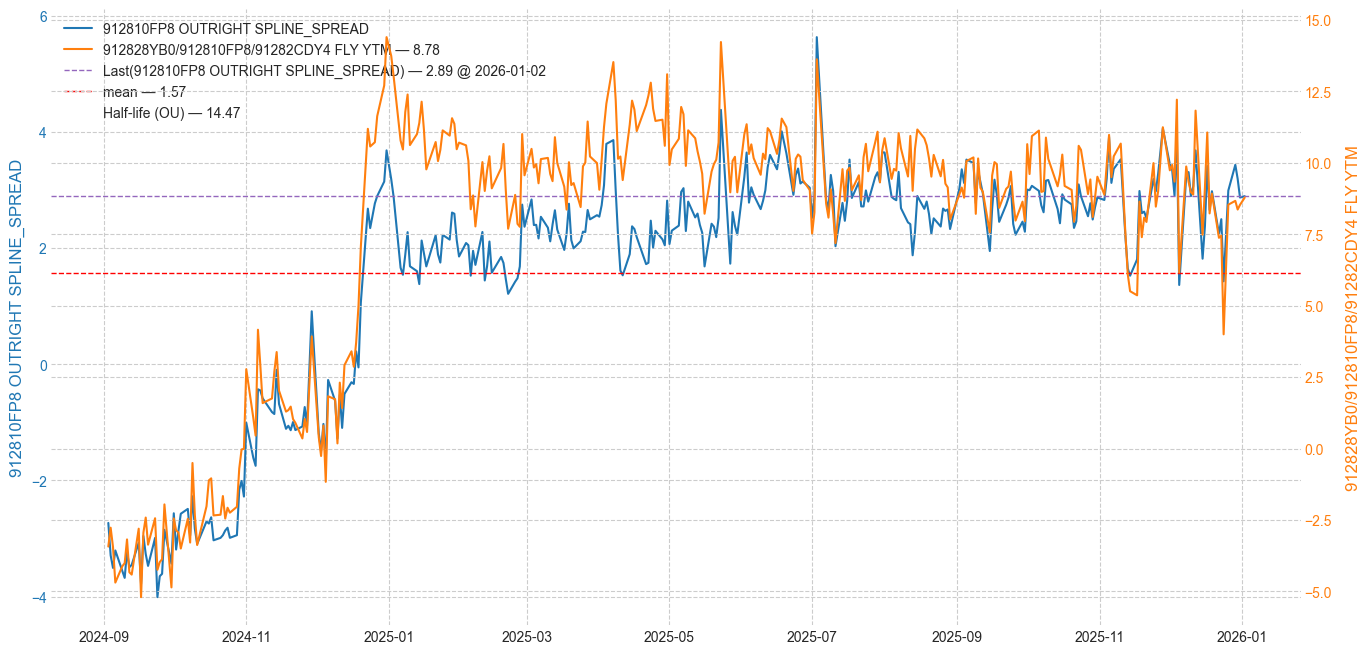

In [12]:
if not res.trade_log.empty and (res.trade_log["event"] == "ENTER").any():
    best = res.trade_log[res.trade_log["event"] == "ENTER"].sort_values("zsig_bp").iloc[-1]
    legs = best["fly_id"].split("-")
    ts_start, ts_end = start, end

    q_fly = FixedRateBondQuery(cusip="/".join(legs), value=FixedRateBondValue.YTM)
    q_belly = FixedRateBondQuery(cusip=legs[1], value=FixedRateBondValue.SPLINE_SPREAD)

    df = tb.get_timeseries(start=ts_start, end=ts_end, queries=[q_fly, q_belly],
                           n_jobs=8, drop_multilevel_cols=True)
    print(f"fly {best['fly_id']} entered {best['date']} at ZSig {best['zsig_bp']:.2f}bp")

    plot, fig, ax, ax2, legend = make_secondary_axis_plot()
    plot(df[df.columns[0]], which="left", indicators=[
        {"kind": "last", "show_date": True, "style": {"linestyle": "--", "color": "tab:purple"}},
        {"kind": "simple_avg", "label": "mean", "style": {"linestyle": "--", "color": "red"}},
        {"kind": "half_life", "method": "ou", "demean": True, "hide": True},
    ])
    if len(df.columns) > 1:
        plot(df[df.columns[1]], which="right")
    legend(); plt.show()
else:
    print("no entries in this window — nothing to plot")

## 7. Verdict

The questions worth asking of this book, in the order they kill it:

1. **Does it trade at all?** `run_gss_backtest` asserts it does; a flat equity curve from a book
   that never entered is the failure mode this strategy is most prone to, because the entry gate
   is a product of two things that are each rarely large.
2. **Does the vol-scaled signal clear the round trip?** `ZSig` at entry against `rt_cost_bp` in the
   candidate table is the whole economic argument. If the median entry `ZSig` is not comfortably
   above the round trip, the rest is noise.
3. **Does the cost assumption carry the result?** Re-run with `CostConfig(cost_legs="belly_only")`
   — the original's rule. If the verdict flips, the strategy is an artefact of charging two legs
   at zero.
4. **Does the wing-selection fix matter?** Re-run with `FlyConfig(wing_objective="legacy_ttm_bug")`.
   A result that only survives under the typo is not a result.

In [13]:
variants = {
    "default (all legs, fixed wings)": cfg,
    "belly-only costs (the original's rule)": GSSConfig(costs=CostConfig(cost_legs="belly_only")),
    "legacy wing objective (the typo)": GSSConfig(fly=FlyConfig(wing_objective="legacy_ttm_bug")),
}
rows = []
for name, c in variants.items():
    try:
        r = run_gss_backtest(panel, usts_mdp, cfg=c, repo_curve=repo, show_progress=False, strict=False)
        s = r.summary()
        rows.append({"variant": name, **{k: s.get(k) for k in
                     ("closed_trades", "end_equity_usd", "net_realized_usd", "avg_per_trade_usd",
                      "hit_rate", "median_hold_days")}})
    except Exception as exc:
        rows.append({"variant": name, "closed_trades": f"FAILED: {type(exc).__name__}"})
display(pd.DataFrame(rows).set_index("variant"))

,closed_trades,end_equity_usd,net_realized_usd,avg_per_trade_usd,hit_rate,median_hold_days
variant,,,,,,
"default (all legs, fixed wings)",34,-4.254352e+06,None,75879.628244,None,7.5
belly-only costs (the original's rule),34,-1.356877e+06,None,161099.484813,None,7.5
legacy wing objective (the typo),24,-1.514717e+06,None,339679.839271,None,5.5
